# ATom-1 box model - minimal set of inputs
This notebook contains calculations for the zero-dimensional box model with a minimal set of inputs.

---

## Part 1: Exploratory data analysis

In [4]:
# Read in dataframe
import pandas as pd
df = pd.read_csv("MDS_atom1_2016_summer_with_no_no2_oh_ho2_full_js.csv")

In [5]:
df.shape

(6550, 144)

In [6]:
df.head()

,Unnamed: 0,UTC_Start_dt,ATom_parcel,Start_UTC,Date,Research Flight Number,Latitude,Longitude,Altitude,Pres,...,jNO2_dnwFrac_CAFS,jNO3_NO2_O3P_CAFS,jNO3_NO_O2_CAFS,jO3_O2_O1D_CAFS,jO3_dnwFrac_CAFS,jPAN_CH3COO2_NO2_CAFS,jPAN_CH3COO_NO3_CAFS,jPropanal_CH2CH3_HCO_CAFS,lat,lon
0,121,2016-07-29 14:56:10,1000122,53770,20160729,1,33.01171,-118.89800,8804.58,343.334,...,0.668625,0.210835,0.025632,0.000009,0.703450,2.479964e-07,1.062842e-07,0.000018,33.01171,241.10200
1,124,2016-07-29 14:56:40,1000125,53800,20160729,1,32.96985,-118.95240,8931.10,337.478,...,0.665000,0.212448,0.025815,0.000009,0.702175,2.504532e-07,1.073371e-07,0.000018,32.96985,241.04760
2,127,2016-07-29 14:57:10,1000128,53830,20160729,1,32.92798,-119.00677,9057.14,331.741,...,0.660525,0.214809,0.026108,0.000009,0.696450,2.547722e-07,1.091881e-07,0.000019,32.92798,240.99323
3,136,2016-07-29 14:58:40,1000137,53920,20160729,1,32.80281,-119.16970,9425.14,315.391,...,0.644500,0.221572,0.026932,0.000010,0.690775,2.613555e-07,1.120095e-07,0.000020,32.80281,240.83030
4,139,2016-07-29 14:59:10,1000140,53950,20160729,1,32.76114,-119.22341,9550.39,309.998,...,0.640600,0.223360,0.027156,0.000010,0.689000,2.626297e-07,1.125556e-07,0.000021,32.76114,240.77659


Filtering out the dataset to only keep the columns of interest:

In [8]:
df = df[['Temp', 'Pres','UTC_Start_dt', 'lat', 'lon', 'Altitude', 'jO3_O2_O1D_CAFS', 'O3_M', 'H2O_M', 'OH_ATHOS', 'HO2_ATHOS', 'CO_M', 'CH4_M', 'NOX_M', 'NO_CL', 'HNO3_M']]
df

,Temp,Pres,UTC_Start_dt,lat,lon,Altitude,jO3_O2_O1D_CAFS,O3_M,H2O_M,OH_ATHOS,HO2_ATHOS,CO_M,CH4_M,NOX_M,NO_CL,HNO3_M
0,249.265,343.334,2016-07-29 14:56:10,33.01171,241.10200,8804.58,0.000009,8.640570e-08,0.000447,0.300,6.444,7.233967e-08,0.000002,9.948500e-11,0.063649,3.272000e-10
1,248.771,337.478,2016-07-29 14:56:40,32.96985,241.04760,8931.10,0.000009,7.601130e-08,0.000332,0.300,5.367,6.900650e-08,0.000002,9.693500e-11,0.063389,3.104400e-10
2,248.851,331.741,2016-07-29 14:57:10,32.92798,240.99323,9057.14,0.000009,8.291030e-08,0.000158,0.300,4.633,7.108760e-08,0.000002,9.569200e-11,0.074402,3.491900e-10
3,246.160,315.391,2016-07-29 14:58:40,32.80281,240.83030,9425.14,0.000010,8.132570e-08,0.000169,0.276,6.063,6.804040e-08,0.000002,9.645400e-11,0.073041,3.308700e-10
4,245.201,309.998,2016-07-29 14:59:10,32.76114,240.77659,9550.39,0.000010,8.148520e-08,0.000207,0.276,6.233,6.748330e-08,0.000002,1.144770e-10,0.069717,2.892000e-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6545,287.376,734.283,2016-08-23 19:51:00,34.94797,242.36580,2818.77,0.000048,5.419620e-08,0.007266,0.227,43.328,1.485790e-07,0.000002,4.076800e-11,0.010443,1.799500e-10
6546,288.683,749.875,2016-08-23 19:51:30,34.91515,242.35962,2641.88,0.000047,5.082710e-08,0.007460,0.227,43.173,1.320212e-07,0.000002,4.127300e-11,0.014422,1.794200e-10
6547,290.545,771.085,2016-08-23 19:52:00,34.88332,242.34174,2403.69,0.000046,5.125980e-08,0.007838,0.240,43.017,1.325316e-07,0.000002,7.323400e-11,0.015064,1.858900e-10
6548,291.259,777.013,2016-08-23 19:52:30,34.85163,242.32323,2339.75,0.000046,5.167830e-08,0.007777,0.240,48.457,1.355386e-07,0.000002,7.178500e-11,0.021050,1.843600e-10


In [9]:
import numpy as np

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6550 entries, 0 to 6549
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Temp             6550 non-null   float64
 1   Pres             6550 non-null   float64
 2   UTC_Start_dt     6550 non-null   object 
 3   lat              6550 non-null   float64
 4   lon              6550 non-null   float64
 5   Altitude         6550 non-null   float64
 6   jO3_O2_O1D_CAFS  6550 non-null   float64
 7   O3_M             6550 non-null   float64
 8   H2O_M            6550 non-null   float64
 9   OH_ATHOS         6550 non-null   float64
 10  HO2_ATHOS        6550 non-null   float64
 11  CO_M             6550 non-null   float64
 12  CH4_M            6550 non-null   float64
 13  NOX_M            6550 non-null   float64
 14  NO_CL            6550 non-null   float64
 15  HNO3_M           6550 non-null   float64
dtypes: float64(15), object(1)
memory usage: 818.9+ KB


In [11]:
df.mean(numeric_only = True)

Temp               2.514861e+02
Pres               4.785047e+02
lat                1.882980e+01
lon                2.559855e+02
Altitude           6.797287e+03
jO3_O2_O1D_CAFS    3.120396e-05
O3_M               6.662522e-08
H2O_M              3.564000e-03
OH_ATHOS           2.556285e-01
HO2_ATHOS          1.249669e+01
CO_M               8.076784e-08
CH4_M              1.850161e-06
NOX_M              6.373149e-11
NO_CL              3.335542e-02
HNO3_M             1.368826e-10
dtype: float64

In [12]:
df.min(numeric_only = True)

Temp               2.051720e+02
Pres               1.788970e+02
lat               -6.473159e+01
lon                1.695991e+02
Altitude           1.568900e+02
jO3_O2_O1D_CAFS   -9.189799e-08
O3_M               7.215400e-09
H2O_M              3.779000e-06
OH_ATHOS          -3.800000e-02
HO2_ATHOS         -4.650000e-01
CO_M               2.140420e-08
CH4_M              1.704809e-06
NOX_M              1.000000e-15
NO_CL             -1.419500e-02
HNO3_M             1.000000e-15
dtype: float64

In [13]:
df.max(numeric_only = True)

Temp               3.028440e+02
Pres               1.014602e+03
lat                8.000860e+01
lon                3.453674e+02
Altitude           1.314651e+04
jO3_O2_O1D_CAFS    1.302335e-04
O3_M               4.400936e-07
H2O_M              2.929838e-02
OH_ATHOS           1.955000e+00
HO2_ATHOS          5.983500e+01
CO_M               3.348210e-07
CH4_M              2.007818e-06
NOX_M              1.002477e-08
NO_CL              3.876647e+00
HNO3_M             2.027320e-09
dtype: float64

In [14]:
df.std(numeric_only = True)

Temp               2.509002e+01
Pres               2.429320e+02
lat                3.951152e+01
lon                5.813160e+01
Altitude           3.674819e+03
jO3_O2_O1D_CAFS    2.115024e-05
O3_M               6.996312e-08
H2O_M              6.302623e-03
OH_ATHOS           2.324705e-01
HO2_ATHOS          8.769121e+00
CO_M               3.063725e-08
CH4_M              4.346564e-08
NOX_M              1.482176e-10
NO_CL              6.959220e-02
HNO3_M             2.495005e-10
dtype: float64

## Part 2: Constructing the box model

First converting timezone to New York. While the ATom-1 mission measured from a range of longitudes and therefore a range of timezones between UTC and UTC-9, it will be easier to use the most central timezone (UTC-4), as this is only for visualisation purposes in the timeseries plots.

In [17]:
# Converting timezone
from datetime import datetime, timezone, date, time
import numpy as np
from pytz import timezone
df["UTC_Start_dt"] = pd.to_datetime(df["UTC_Start_dt"])
df['UTC_Start_dt'] = df['UTC_Start_dt'].dt.tz_localize('UTC')
df["UTC_Start_dt"] = df["UTC_Start_dt"].dt.tz_convert('America/New_York')
df['date'] = df['UTC_Start_dt']

## Finding $[M]$
For rate constants - temperature dependent so use Arrhenius equation: $k = Ae^{-\frac{E_a}{RT}}$

Convert units for species so that everything is in units of $molecules \: cm^{-3}$ and calculate $[M]$ using $[M] = \frac{p}{kT}$ ($p$ is pressure in $Pa$, $k$ is Boltzmann's constant in $J \: K^-1$ and $T$ is temperature in $K$

$1 J = 1 \: kg \: m^2 \: s^{-2}$

$1 \: Pa = 1 \: N m^{-2}$

Multiply value of $[M]$ by $1 \times 10^{-6}$, so from $molecules \: m^{-3}$ to $molecules \: cm^{-3}$

In [19]:
kb = 1.38e-23 # J K^−1 Boltzmann's constant

for i in range(len(df)):
    df.loc[i, "M"] = ((df.loc[i, "Pres"] * 100) / (kb * df.loc[i, "Temp"])) * 1e-6 ## molecules cm^3, pressure was in hPa so multiplied by 100 to Pa

df.head()

,Temp,Pres,UTC_Start_dt,lat,lon,Altitude,jO3_O2_O1D_CAFS,O3_M,H2O_M,OH_ATHOS,HO2_ATHOS,CO_M,CH4_M,NOX_M,NO_CL,HNO3_M,date,M
0,249.265,343.334,2016-07-29 10:56:10-04:00,33.01171,241.10200,8804.58,0.000009,8.640570e-08,0.000447,0.300,6.444,7.233967e-08,0.000002,9.948500e-11,0.063649,3.272000e-10,2016-07-29 10:56:10-04:00,9.981054e+18
1,248.771,337.478,2016-07-29 10:56:40-04:00,32.96985,241.04760,8931.10,0.000009,7.601130e-08,0.000332,0.300,5.367,6.900650e-08,0.000002,9.693500e-11,0.063389,3.104400e-10,2016-07-29 10:56:40-04:00,9.830297e+18
2,248.851,331.741,2016-07-29 10:57:10-04:00,32.92798,240.99323,9057.14,0.000009,8.291030e-08,0.000158,0.300,4.633,7.108760e-08,0.000002,9.569200e-11,0.074402,3.491900e-10,2016-07-29 10:57:10-04:00,9.660079e+18
3,246.160,315.391,2016-07-29 10:58:40-04:00,32.80281,240.83030,9425.14,0.000010,8.132570e-08,0.000169,0.276,6.063,6.804040e-08,0.000002,9.645400e-11,0.073041,3.308700e-10,2016-07-29 10:58:40-04:00,9.284376e+18
4,245.201,309.998,2016-07-29 10:59:10-04:00,32.76114,240.77659,9550.39,0.000010,8.148520e-08,0.000207,0.276,6.233,6.748330e-08,0.000002,1.144770e-10,0.069717,2.892000e-10,2016-07-29 10:59:10-04:00,9.161310e+18


## Source rate

Calculate $[O^1D]$ using $[O^1D]_{SS} = \frac{J[O_3]}{k_1[H_2O] + k_2[M]}$

(After the conversion to $molecules \: cm^{-3}$ for the other concentrations, $[M]$ cancels out to become 1, but it is technically still included in the rate equation)

Need to calculate $[O^1D]$ indirectly using data for $[O_3]$

Source:

$O_3 + hv → O_2 + O(^1D)$

Sink:

$O(^1D) + M → O(^3P) + M$

$O(^1D) + H_2O → 2OH$

Assumed to be in steady state - due to its high reactivity and short lifetime

So $\frac{d[O^1D]}{dt} = j[O_3] - k_1[O^1D][H_2O] - k_2[O^1D] = 0$

$[O^1D]_{SS} = \frac{j[O_3]}{k_1[H_2O] + k_2[M]}$

$(M = \frac{p}{kT})$

$k = Ae^{-\frac{E_a}{RT}}$ to calculate temperature dependent rate constants (with exception of $k_{OH+CO}$, see report for details on this)

In [22]:
df['kH2O'] = 1.63e-10 * np.exp(-(-60/df["Temp"])) ## page 21 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df['kM'] = 2.15e-11 * np.exp(-(-110/df["Temp"])) ## page 21 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df['kHO2NO'] = 3.44e-12 * np.exp(-(-260/df["Temp"])) ## page 83 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df['kHO2O3'] = 1.0e-14 * np.exp(-(490/df["Temp"])) ## page 67 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf

# New columns for conversion from mole fraction to molecules cm^-3
df["O3"] = df["O3_M"] * df["M"]
df["H2O"] = df["H2O_M"] * df["M"]
df["HO2"] = df["HO2_ATHOS"] * 1e-12 * df["M"]
df["NO"] = df["NOX_M"] * df["M"]

df["[OH]_measured"] = df["OH_ATHOS"] * 1e-12 * df["M"] # in ppt

df["O1D"] = (df["jO3_O2_O1D_CAFS"] * df["O3_M"]) / ((df['kH2O'] * df["H2O_M"]) + (df['kM']))

df.columns

Index(['Temp', 'Pres', 'UTC_Start_dt', 'lat', 'lon', 'Altitude',
       'jO3_O2_O1D_CAFS', 'O3_M', 'H2O_M', 'OH_ATHOS', 'HO2_ATHOS', 'CO_M',
       'CH4_M', 'NOX_M', 'NO_CL', 'HNO3_M', 'date', 'M', 'kH2O', 'kM',
       'kHO2NO', 'kHO2O3', 'O3', 'H2O', 'HO2', 'NO', '[OH]_measured', 'O1D'],
      dtype='object')

In [23]:
for i in range(len(df)):
    df.loc[i, "source"] = (2 * df['kH2O'][i] * df["O1D"][i] * df["H2O"][i]) 
print(df["source"].mean())
df.head()
# source should be around 10e5 molecules cm^-3 s^-1

print("Source rates (in molecules cm^-3 s^-1):")
print("O1D contribution: ", (2 * df['kH2O'] * df["O1D"] * df["H2O"]).mean())
print("NO contribution: ", (df['kHO2NO'] * df["HO2"] * df["NO"]).mean())
print("HO2 contribution: ", (df['kHO2O3'] * df["HO2"] * df["O3"]).mean())

714621.1551027566
Source rates (in molecules cm^-3 s^-1):
O1D contribution:  714621.1551027566
NO contribution:  1319199.8459436973
HO2 contribution:  178178.66999201934


### A sense check of the values of the rate constants at 298K - checking that the calculations here are correct and agree with literature

In [25]:
print("k for reaction of O1D + H2O:", 1.63e-10 * np.exp(--60/298), "lit: 2.0e-10")
print("k for reaction of H2O + NO:", 3.44e-12 * np.exp(--260/298), "lit: 8.2e-12")
print("k for reaction of HO2 + O3:", 1.0e-14 * np.exp(-490/298), "lit: 1.9e-15")

k for reaction of O1D + H2O: 1.9935606209813077e-10 lit: 2.0e-10
k for reaction of H2O + NO: 8.231388338450365e-12 lit: 8.2e-12
k for reaction of HO2 + O3: 1.9314862629435327e-15 lit: 1.9e-15


## Box model equation to find [OH]

## Steady state of OH and sinks

Use the sink rate coefficients here

$OH + CO → H + CO2$

Rate coefficient = $k[CO]$

$OH + CH_4 → CH_3 + H_2O$

Rate coefficient = $k[CH_4]$

As $\frac{d[OH]}{dt} = Σsources - Σsinks$

$\frac{d[OH]}{dt} = P(OH) - k_1[OH][CO] - k_2[CH_4][OH]$

At steady state the sources and sinks balance:

$P(OH) - k_1[OH][CO] - k_2[CH_4][OH] = 0$

We can use the steady state approximation to rearrange to find $[OH]$ from the other known values

$P(OH) = sum of source rates

$[OH] = \frac{p(OH)}{(k_1[CO] + k_2[CH4] + k_3[O_3] + k_4[HNO_3]}$

Additional sinks being added:

$OH + O_3 → HO_2 + O_2$

Rate coefficient $k[O_3]$

$OH + HNO_3 → H_2O + NO_2$

Rate coefficient $k[HNO_3]$

In [29]:
# Calculating rate coefficients for sink terms
df["P_atm"] = 0.000987 * df["Pres"]
# df['kCO'] = 1.85e-13 * np.exp(-(65/df['Temp'])) ## page 484 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df['kCO']  = 1.5e-13  * (1.0 + 0.6 * df["P_atm"]) #where P is the pressure in atmospheres
df['kCH4'] = 2.45e-12 * np.exp(-(1775/df['Temp'])) ## page 106 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf

df["CO"] = df['CO_M'] * df["M"]
df["CH4"] = df['CH4_M'] * df["M"]

# Calculating [OH]
for i in range(len(df)):
    df.loc[i, "[OH]_calc"] = (df.loc[i, "source"]) / ((df['kCO'][i] * df["CO"][i]) + (df['kCH4'][i] * df["CH4"][i]))

# Sink contributions
print("Sink rate coefficients (in molecules^-1 cm^3 s^-1):")
print("CO contribution: ", (df['kCO'] * df["CO"]).mean())
print("CH4 contribution: ", (df['kCH4'] * df["CH4"]).mean())

Sink rate coefficients (in molecules^-1 cm^3 s^-1):
CO contribution:  0.2212206016619309
CH4 contribution:  0.07669693114608837


### A second sense check of the sink rate constants...

In [31]:
# print("k for reaction of OH + CO:", 1.85e-13 * np.exp(-(65/298)), "lit: 2.4e-13")
print("k for reaction of OH + CO:", 1.5e-13  * (1.0 + 0.6 * 1), "lit: 2.4e-13")
print("k for reaction of OH + CH4:", 2.45e-12 * np.exp(-(1775/298)), "lit: 6.3e-15")

k for reaction of OH + CO: 2.4e-13 lit: 2.4e-13
k for reaction of OH + CH4: 6.343733432497232e-15 lit: 6.3e-15


## Part 3: Plotting results

## Plotting modelled $[OH]_{SS}$ vs measured $[OH]$ from ATom data

First, comparison (between box model and measurement) plots for 2 representative days are shown - 29/07/2016 and 06/08/2016

In [35]:
import matplotlib.dates as mdates

### Timeseries plots

In [37]:
# If cartopy is not installed, run this
# !pip install cartopy

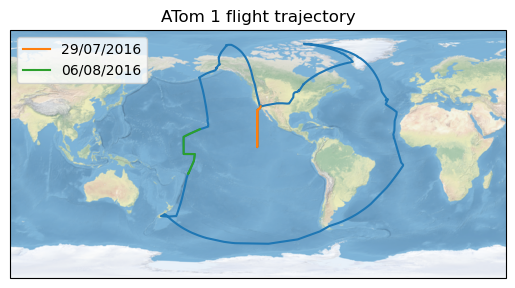

In [38]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=240))
ax.stock_img()
plt.rcParams.update({'font.size':10})
plt.plot(df["lon"], df["lat"], transform=ccrs.Geodetic())
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
plt.title("ATom 1 flight trajectory")

plt.plot(df["lon"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], df["lat"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], transform=ccrs.Geodetic(), label = "29/07/2016")
plt.plot(df["lon"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], df["lat"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], transform=ccrs.Geodetic(), label = "06/08/2016")
plt.legend()

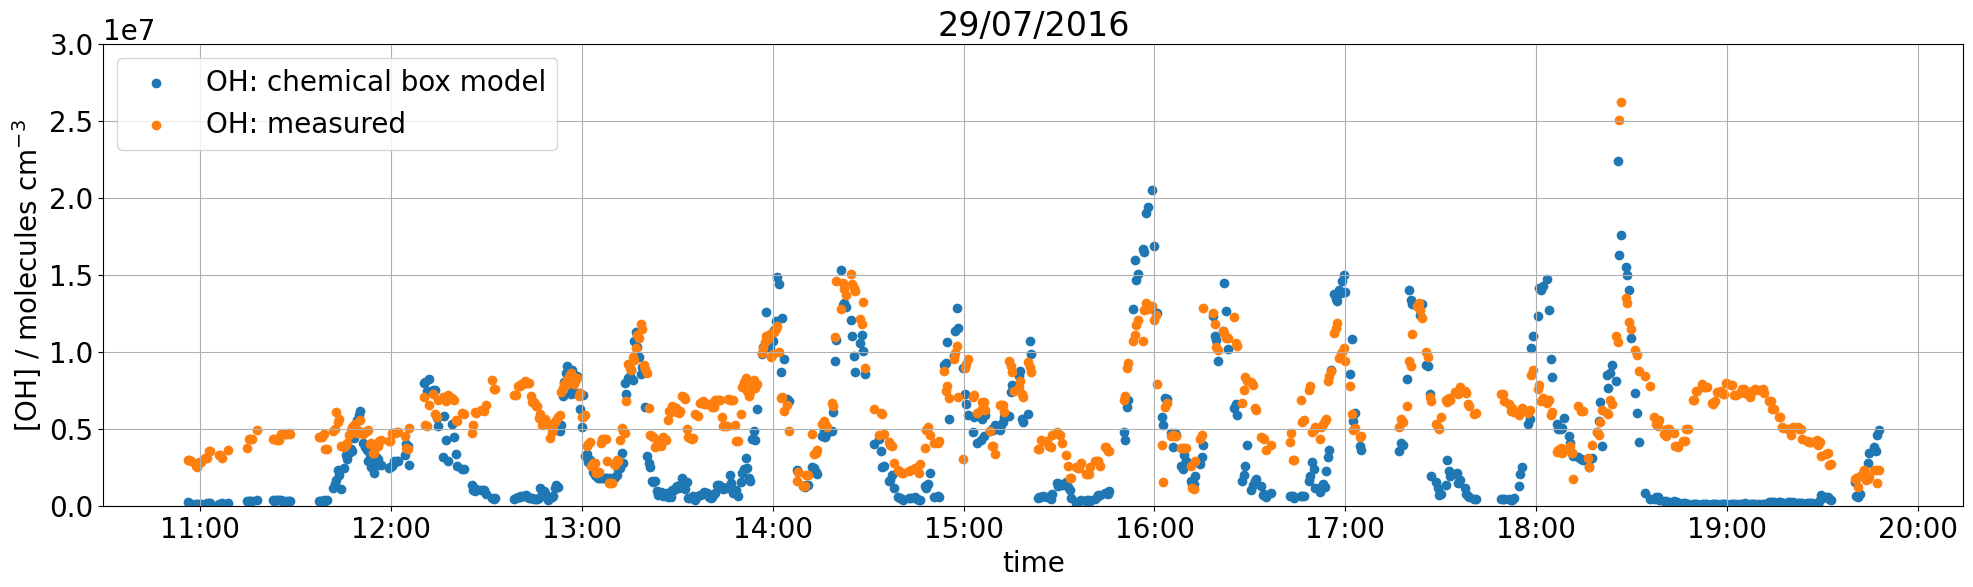

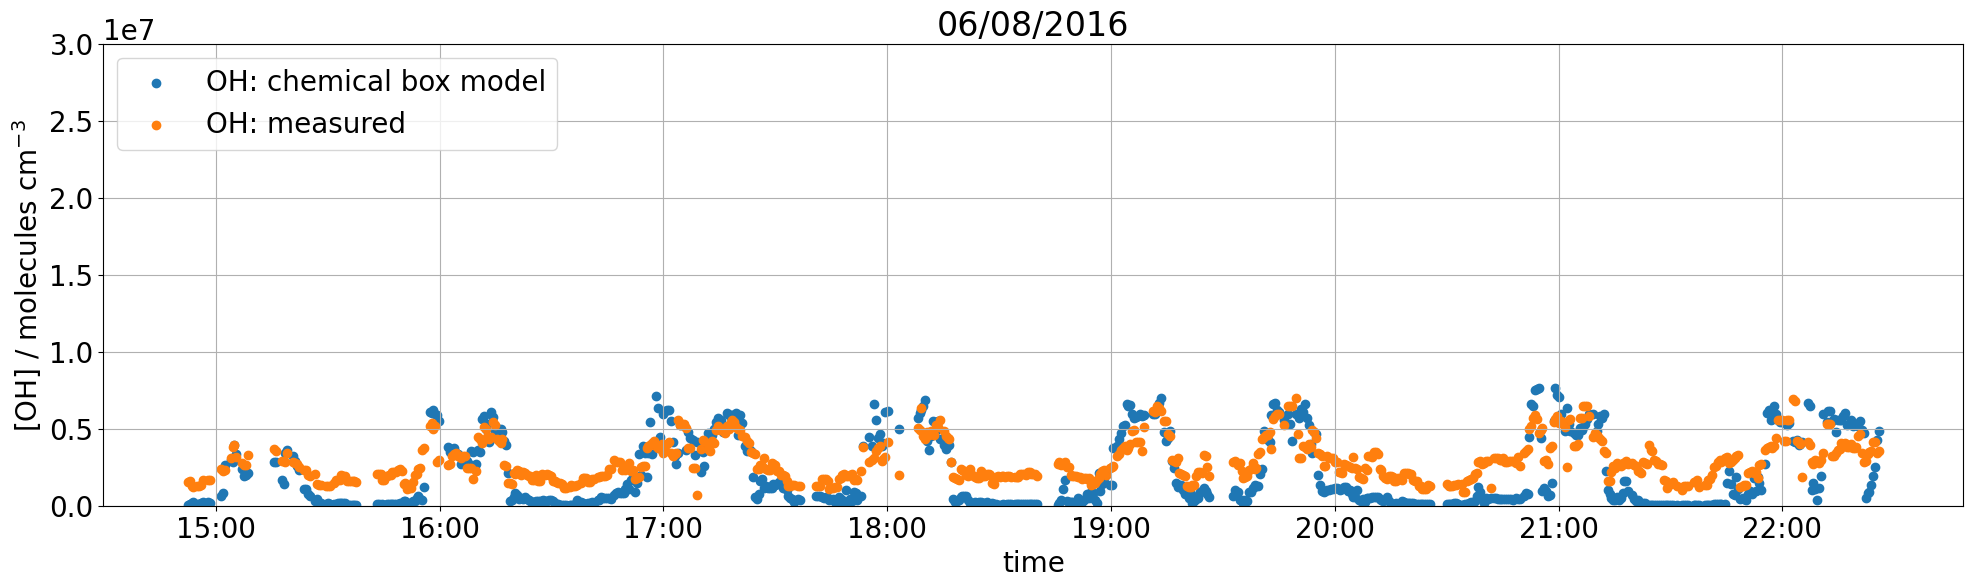

In [39]:
import pytz
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size':20})
fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], y = df["[OH]_calc"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], label = "OH: chemical box model")
plt.xlabel("datetime")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
plt.ylabel("[OH] / molecules cm$^{-3}$")
plt.ylim(0, 3e7)
plt.grid()

plt.scatter(x = df["date"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], y = df["[OH]_measured"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], label = "OH: measured")
plt.xlabel("time")
plt.ylabel("[OH] / molecules cm$^{-3}$")
plt.legend(loc="upper left")
plt.title("29/07/2016")


fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], y = df["[OH]_calc"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], label = "OH: chemical box model")
plt.xlabel("datetime")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
plt.ylabel("[OH] / molecules cm$^{-3}$")
plt.legend()
# fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], y = df["[OH]_measured"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], label = "OH: measured")
plt.xlabel("time")
plt.ylabel("[OH] / molecules cm$^{-3}$")
plt.ylim(0, 3e7)
plt.legend(loc="upper left")
plt.title("06/08/2016")
plt.grid()

Same plot below, but with addition of altitude line.

Text(0.5, 1.0, '06/08/2016')

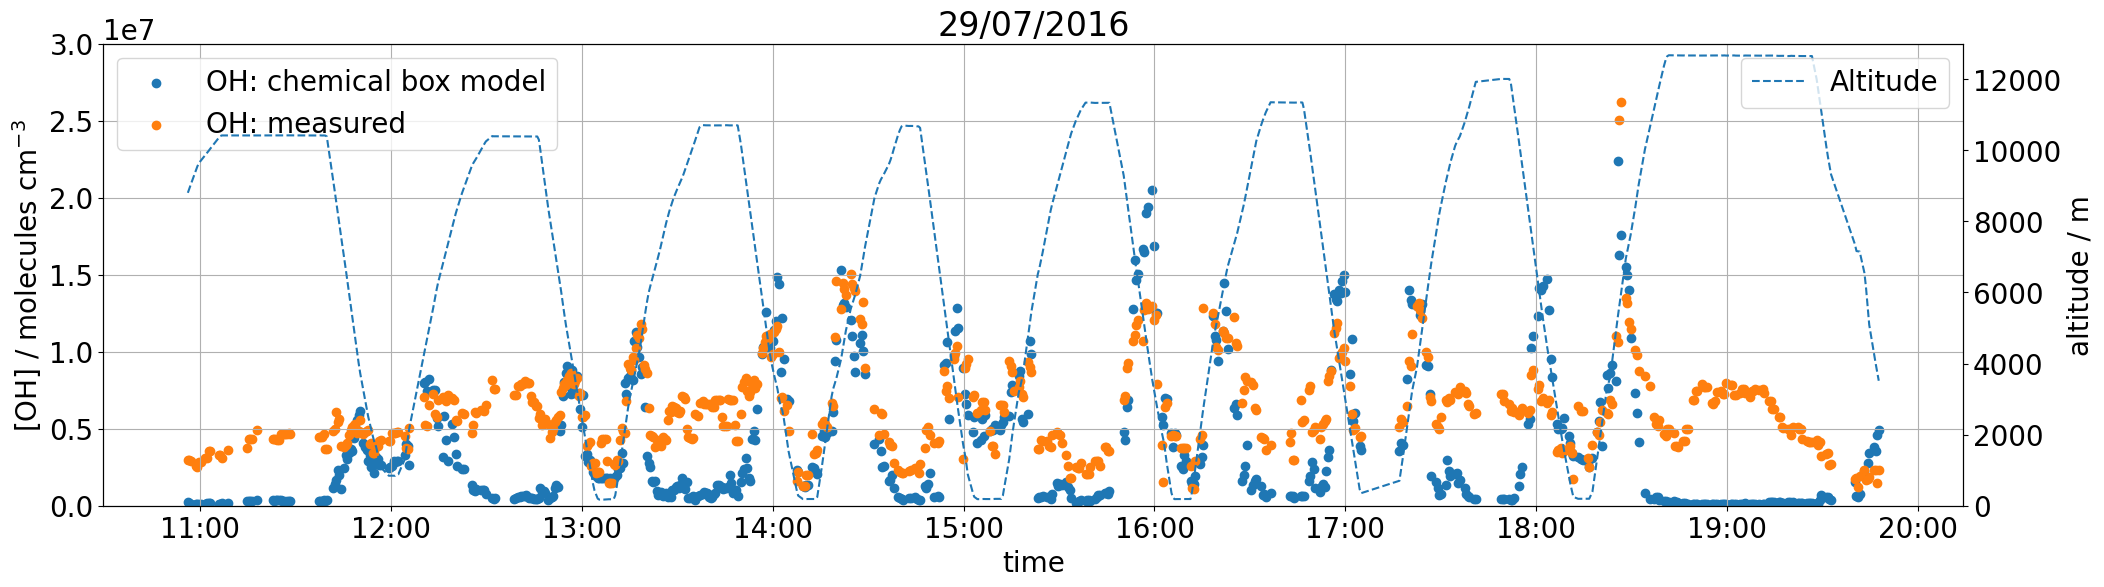

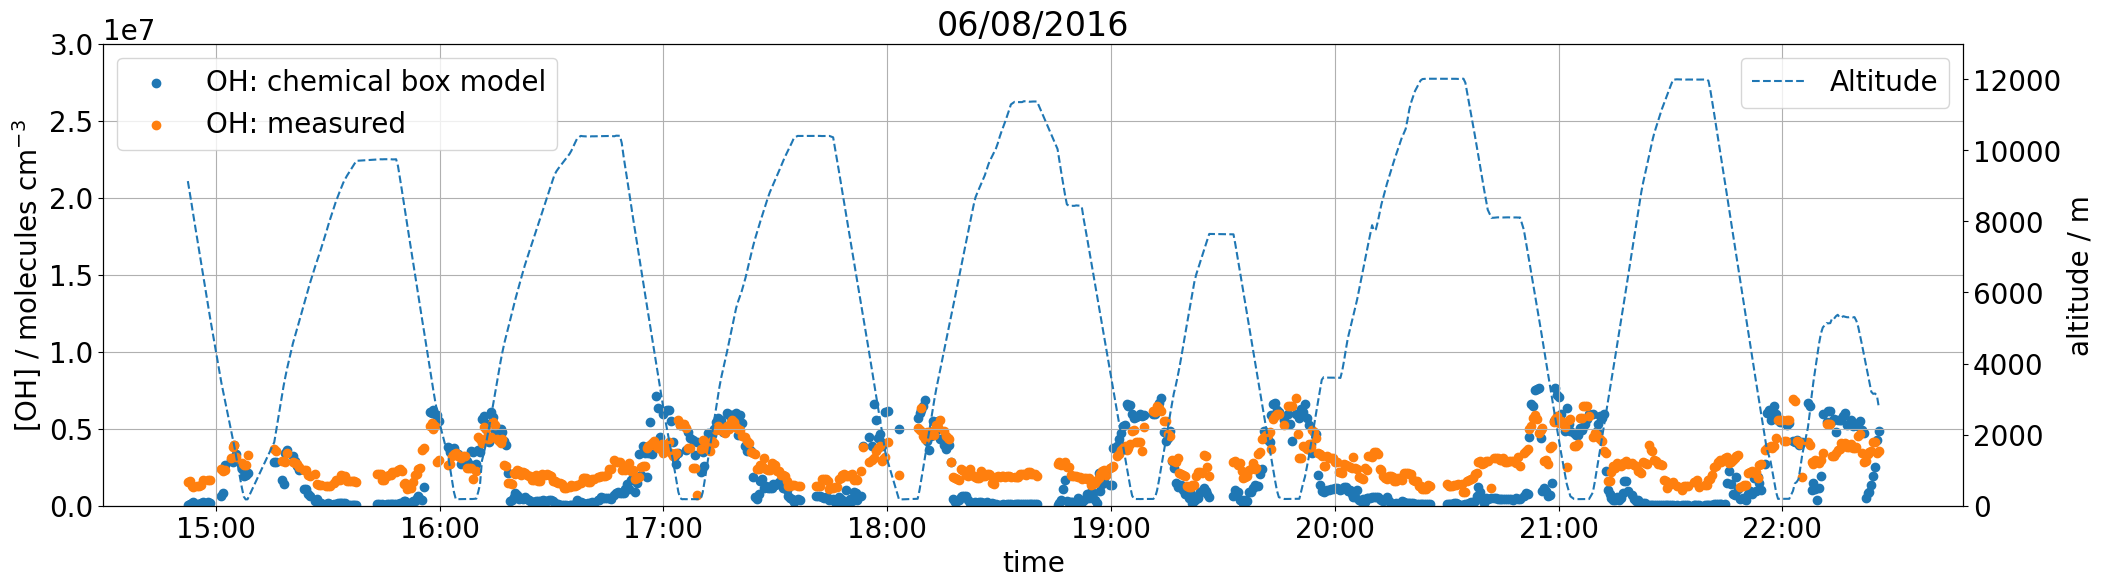

In [41]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size':20})
fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.scatter(x = df["date"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], y = df["[OH]_calc"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], label = "OH: chemical box model")
ax1.set_xlabel("time")
ax1.set_ylabel("[OH] / molecules cm$^{-3}$")
ax1.set_ylim(0, 3e7)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
ax1.legend()
ax1.scatter(x = df["date"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], y = df["[OH]_measured"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], label = "OH: measured")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.set_ylabel('altitude / m')
ax2.plot(df["date"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], df["Altitude"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], linestyle='--', label = "Altitude")
ax2.set_ylim(0, 13000)
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("29/07/2016")


fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.scatter(x = df["date"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-08")], y = df["[OH]_calc"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-08")], label = "OH: chemical box model")
ax1.set_xlabel("time")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
ax1.set_ylabel("[OH] / molecules cm$^{-3}$")
ax1.set_ylim(0, 3e7)
ax1.scatter(x = df["date"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-08")], y = df["[OH]_measured"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-08")], label = "OH: measured")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.set_ylabel('altitude / m')
ax2.plot(df["date"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-08")], df["Altitude"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-08")], linestyle='--', label = "Altitude")
ax2.set_ylim(0, 13000)
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("06/08/2016")

Can see that box model tends to underpredict at high altitudes. Would be more helpful to calculate some quantitative metrics (i.e. r^2 and RMSE)

In [43]:
import sklearn
from sklearn import metrics
X = df[["[OH]_measured"]][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")]
y = df["[OH]_calc"][(df["date"] > "2016-07-28") & (df["date"] < "2016-08-01")]
print(f"r2 for 28/07/2016: {round(sklearn.metrics.r2_score(X, y), 2)}")
print(f"RMSE for 28/07/2016: {format(sklearn.metrics.root_mean_squared_error(X, y), ".3e")}")

X = df[["[OH]_measured"]][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")]
y = df["[OH]_calc"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")]
print(f"r2 for 05/08/2016: {round(sklearn.metrics.r2_score(X, y), 2)}")
print(f"RMSE for 06/08/2016: {format(sklearn.metrics.root_mean_squared_error(X, y), ".3e")}")

X = df[["[OH]_measured"]]
y = df["[OH]_calc"]
print(f"r2 for whole dataset: {round(sklearn.metrics.r2_score(X, y), 2)}")
print(f"RMSE for whole dataset: {format(sklearn.metrics.root_mean_squared_error(X, y), ".3e")}")

r2 for 28/07/2016: -0.76
RMSE for 28/07/2016: 3.873e+06
r2 for 05/08/2016: -0.49
RMSE for 06/08/2016: 1.595e+06
r2 for whole dataset: 0.1
RMSE for whole dataset: 2.466e+06


Can go one step further and see if there is trend between r^2 or RMSE and altitude
First, take a look at distributions of altitudes across the dataset:

(array([ 758.,  512.,  584.,  467.,  546.,  567.,  886., 1177.,  763.,
         290.]),
 array([  156.89 ,  1455.852,  2754.814,  4053.776,  5352.738,  6651.7  ,
         7950.662,  9249.624, 10548.586, 11847.548, 13146.51 ]),
 <BarContainer object of 10 artists>)

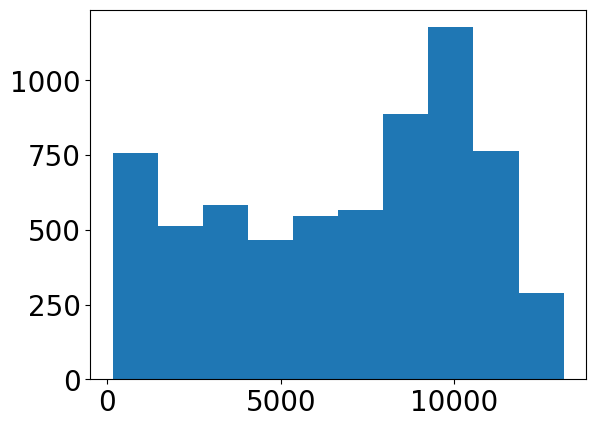

In [45]:
plt.hist(df["Altitude"])

There are more data points at high altitudes, so at say above 6000 m, can take averages at more frequent intervals.

In [46]:
numbers = list(range(0, 6000, 1000))
numbers = numbers + (list(range(6000, 13000, 500)))
metrics_r2 = []
metrics_rmse = []
print(numbers)
for i in range(len(numbers) - 1):
    # print(numbers[i+1])
    X = df[["[OH]_measured"]][(df["Altitude"] >= int(numbers[i])) & (df["Altitude"] < int(numbers[i + 1]))]
    y = df["[OH]_calc"][(df["Altitude"] >= int(numbers[i])) & (df["Altitude"] < int(numbers[i + 1]))]
    metrics_r2.append(sklearn.metrics.r2_score(X, y))
    metrics_rmse.append(sklearn.metrics.root_mean_squared_error(X, y))

[0, 1000, 2000, 3000, 4000, 5000, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000, 10500, 11000, 11500, 12000, 12500]


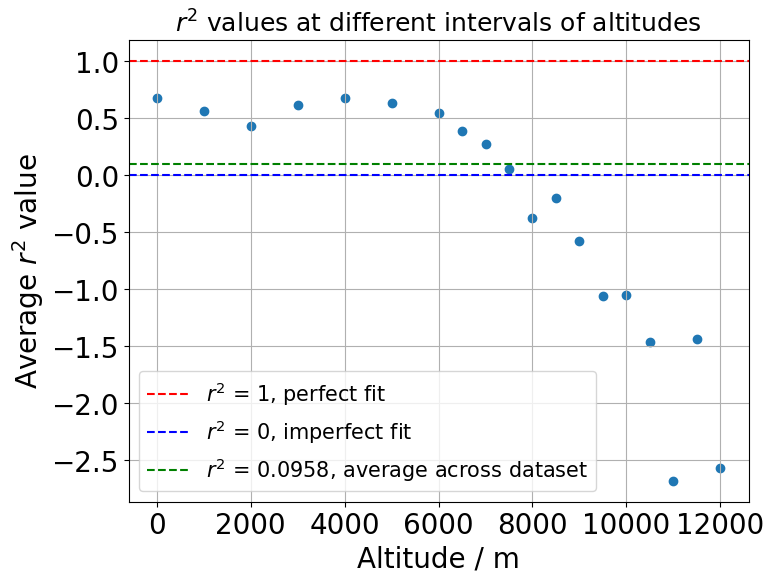

In [47]:
fig, ax = plt.subplots(figsize = (8, 6))
plt.rcParams.update({'font.size':15})

plt.scatter(numbers[:-1], metrics_r2)
plt.axhline(y=1, color='r', linestyle='--', label='${r^2}$ = 1, perfect fit')
plt.axhline(y=0, color='b', linestyle='--', label='${r^2}$ = 0, imperfect fit')
plt.axhline(y = (sklearn.metrics.r2_score(df[["[OH]_measured"]], df["[OH]_calc"])), color = 'g', linestyle = '--', label = f'$r^2$ = {round(sklearn.metrics.r2_score(df[["[OH]_measured"]], df["[OH]_calc"]), 4)}, average across dataset')
plt.xlabel("Altitude / m")
plt.ylabel("Average $r^2$ value")
plt.title("$r^2$ values at different intervals of altitudes")
plt.legend(prop={'size':15})

plt.grid()

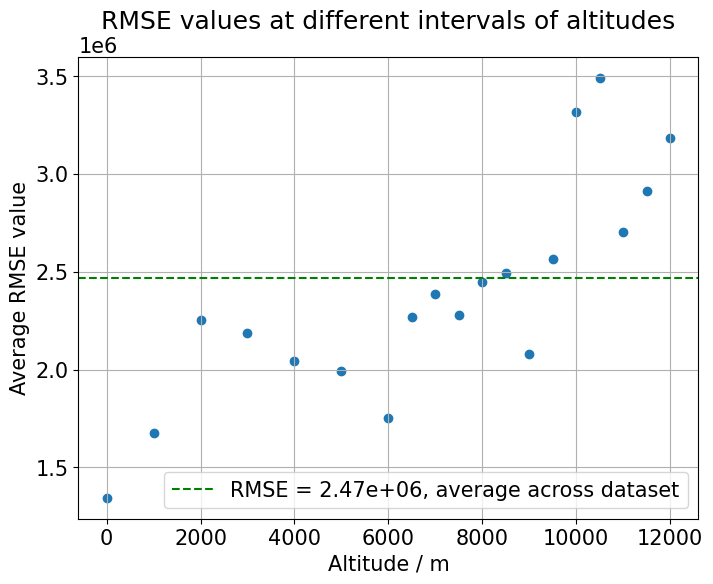

In [48]:
fig, ax = plt.subplots(figsize = (8, 6))
plt.rcParams.update({'font.size':15})

plt.scatter(numbers[:-1], metrics_rmse)
plt.axhline(y = (sklearn.metrics.root_mean_squared_error(df[["[OH]_measured"]], df["[OH]_calc"])), color = 'g', linestyle = '--', label = f'RMSE = {'{:.2e}'.format(sklearn.metrics.root_mean_squared_error(df[["[OH]_measured"]], df["[OH]_calc"]))}, average across dataset')
plt.xlabel("Altitude / m")
plt.ylabel("Average RMSE value")
plt.title("RMSE values at different intervals of altitudes")
plt.legend(prop={'size':15})

plt.grid()

### Plot to identify lat/lon of high RMSE at the low altitudes of 2000-4000m

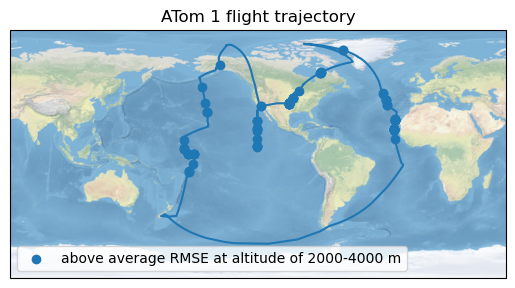

In [50]:
df["residual"] = np.nan
for i in range(len(df)):
    df.loc[i, "residual"] = abs(df.loc[i, "[OH]_measured"] - df.loc[i, "[OH]_calc"])
mask = (df["Altitude"] <= 4000) & (df["Altitude"] <= 2000) & (df["residual"] > sklearn.metrics.root_mean_squared_error(df["[OH]_measured"], df["[OH]_calc"]).mean())
mask = (df["Altitude"] <= 4000) & (df["Altitude"] <= 2000) & (df["residual"] > sklearn.metrics.root_mean_squared_error(df["[OH]_measured"], df["[OH]_calc"]).mean())

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=240))
ax.stock_img()
plt.rcParams.update({'font.size':10})
plt.plot(df["lon"], df["lat"], transform=ccrs.Geodetic())
plt.scatter(df["lon"][mask], df["lat"][mask], label = "above average RMSE at altitude of 2000-4000 m", transform=ccrs.Geodetic())
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
plt.title("ATom 1 flight trajectory")
plt.legend()
plt.show()

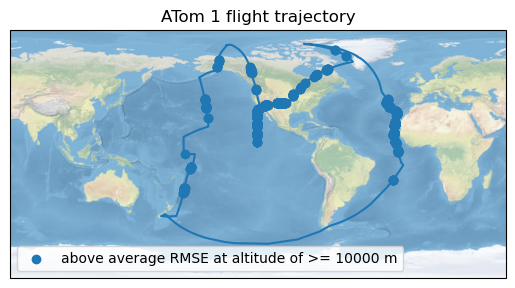

In [51]:
df["residual"] = np.nan
for i in range(len(df)):
    df.loc[i, "residual"] = abs(df.loc[i, "[OH]_measured"] - df.loc[i, "[OH]_calc"])
mask = (df["Altitude"] >= 10000) & (df["residual"] > sklearn.metrics.root_mean_squared_error(df["[OH]_measured"], df["[OH]_calc"]).mean())

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=240))
ax.stock_img()
plt.rcParams.update({'font.size':10})
plt.plot(df["lon"], df["lat"], transform=ccrs.Geodetic())
plt.scatter(df["lon"][mask], df["lat"][mask], label = "above average RMSE at altitude of >= 10000 m", transform=ccrs.Geodetic())
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
plt.title("ATom 1 flight trajectory")
plt.legend()
plt.show()

In [52]:
# Write the dataframe to csv so that the box model output can be used for machine learning
df.to_csv("box_model_output.csv")

r2 score for 2016-07-29: -0.7637383260691928
RMSE for 2016-07-29: 3873015.5625122907
r2 score for 2016-08-01: -1.9533209176467832
RMSE for 2016-08-01: 1657411.378306002
r2 score for 2016-08-03: -0.7110125190184402
RMSE for 2016-08-03: 1748581.2791209035
r2 score for 2016-08-06: -0.48710412336911135
RMSE for 2016-08-06: 1595215.9398863227
r2 score for 2016-08-08: -0.1819258785802056
RMSE for 2016-08-08: 1722939.2475004613
r2 score for 2016-08-12: -0.9243170816187884
RMSE for 2016-08-12: 439466.92758760304
r2 score for 2016-08-15: -0.36180776741870124
RMSE for 2016-08-15: 1284207.2964210776
r2 score for 2016-08-17: -1.0330348261202738
RMSE for 2016-08-17: 3293779.1295896983
r2 score for 2016-08-20: -0.31870244650081037
RMSE for 2016-08-20: 2490195.485294178
r2 score for 2016-08-22: -0.6992488393607728
RMSE for 2016-08-22: 2188507.7816664963
r2 score for 2016-08-23: -0.5292444665346612
RMSE for 2016-08-23: 3705366.092686889


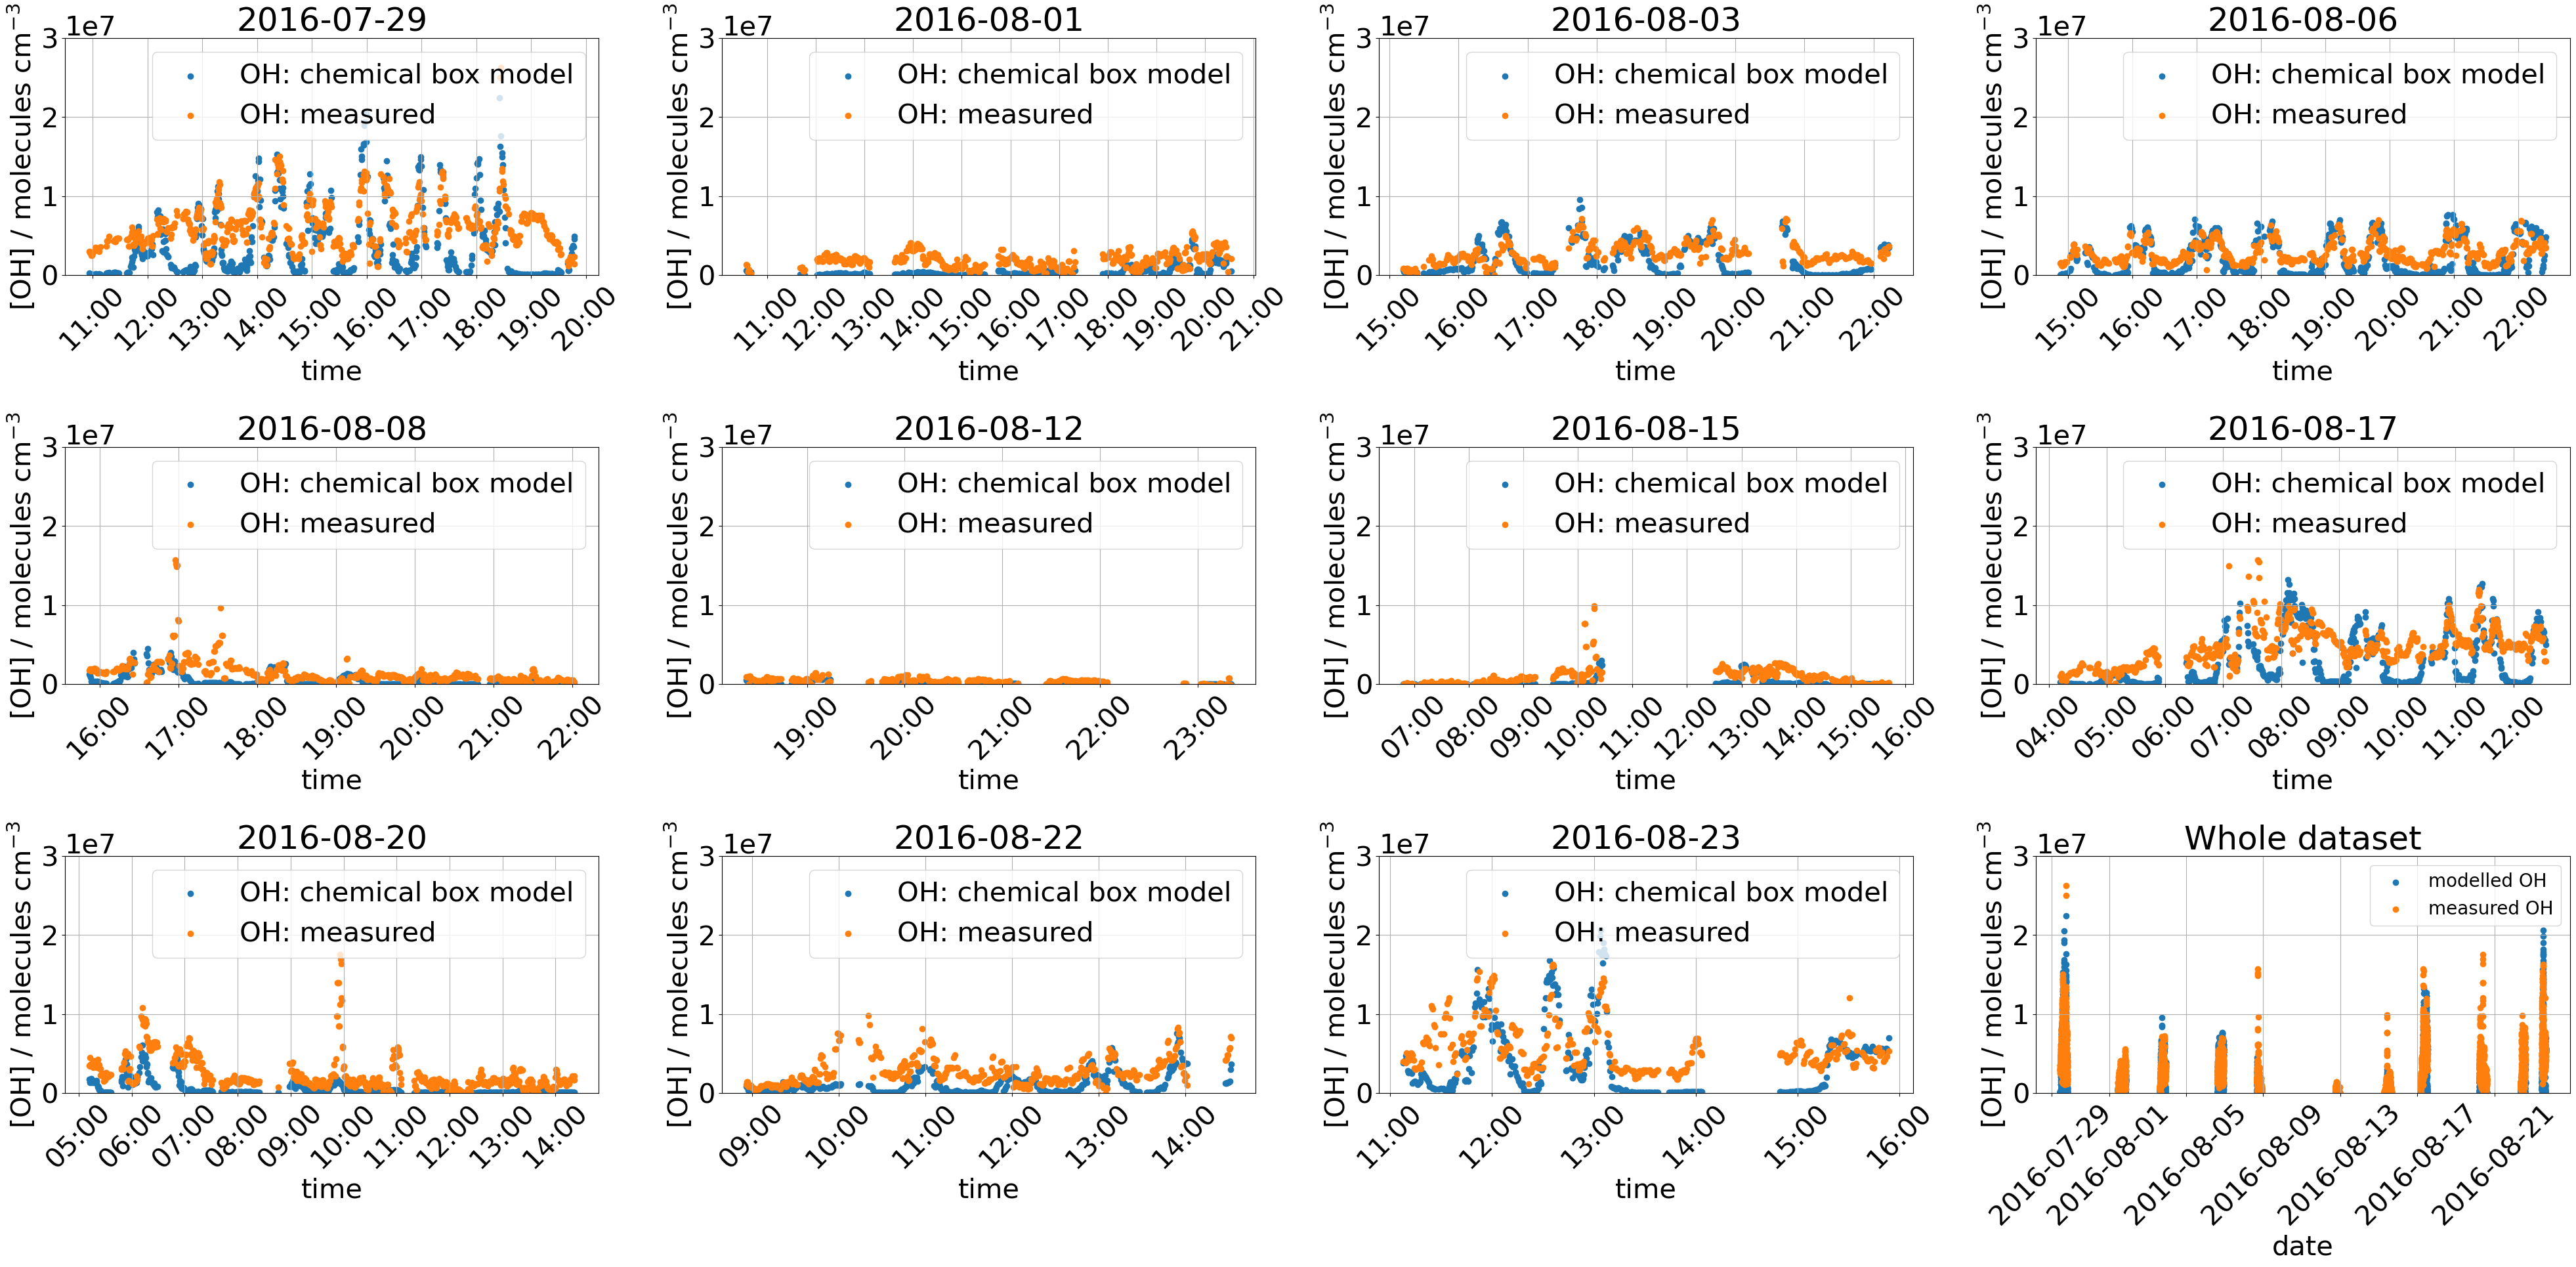

Overall score was: 0.09582400130627777
Overall RMSE was: 2465792.761124978


In [53]:
# Plots for all dates for Appendix
from sklearn.metrics import mean_squared_error
df["date_only"] = df["date"].dt.date
groups = list(df.groupby("date_only"))
plt.rcParams.update({'font.size':30})
fig, axes = plt.subplots(3, 4, figsize=(40, 20), sharex=False, sharey=False)
axes = axes.flatten()  # Flatten to 1D array for easy indexing
plt.ylabel("[OH] / molecules cm$^{-3}$")

for i, (date, group) in enumerate(groups):
    if i >= 16: 
        axes[i].scatter(df["date"], df["[OH]_calc"])
        break
    ax = axes[i]
    ax.scatter(group["date"], group["[OH]_calc"], label="OH: chemical box model")
    ax.scatter(group["date"], group["[OH]_measured"], label="OH: measured")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
    ax.set_title(str(date))
    ax.set_ylim(0, 3e7)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True)
    ax.legend(fontsize=30)
    ax.set_xlabel('time')
    ax.set_ylabel("[OH] / molecules cm$^{-3}$")

    X = group["[OH]_measured"]
    y = group["[OH]_calc"]
    print(f"r2 score for {date}: {sklearn.metrics.r2_score(X, y)}")
    print(f"RMSE for {date}: {sklearn.metrics.root_mean_squared_error(X, y)}")

# Last subplot is for whole dataset
ax = axes[-1]
ax.scatter(df["date"], df["[OH]_calc"], label="modelled OH")
ax.scatter(df["date"], df["[OH]_measured"], label="measured OH")
ax.set_title("Whole dataset")
ax.set_ylim(0, 3e7)
ax.set_xlabel("date")
ax.tick_params(axis='x', rotation=45)
ax.grid(True)
ax.legend(fontsize=8)
plt.legend(prop={'size':20})
plt.tight_layout()
plt.show()

print(f"Overall score was: {sklearn.metrics.r2_score(df["[OH]_measured"], df["[OH]_calc"])}")
print(f"Overall RMSE was: {sklearn.metrics.root_mean_squared_error(df["[OH]_measured"], df["[OH]_calc"])}")